In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [36]:
filepath = '../data/BankChurners.csv'
df = pd.read_csv(filepath)

First, we perform a basic round of EDA before data cleaning;

In [37]:
# viewing features
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [38]:
# dropping unnecessary features
df.drop(['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 
         'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis=1, inplace=True)

In [24]:
# overview of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [25]:
display(df.describe())

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [26]:
# checking for duplicates
df.duplicated().sum()

0

In section 1, we know that:  
1. We get an overview of the data type: there are float numbers, integers, and categorical variables.  
2. There's no missing value or duplicate entry.  
3. We have the five-number summary and some statistics of numerical variables.

Next, we investigate the distribution of features

### Numerical Features

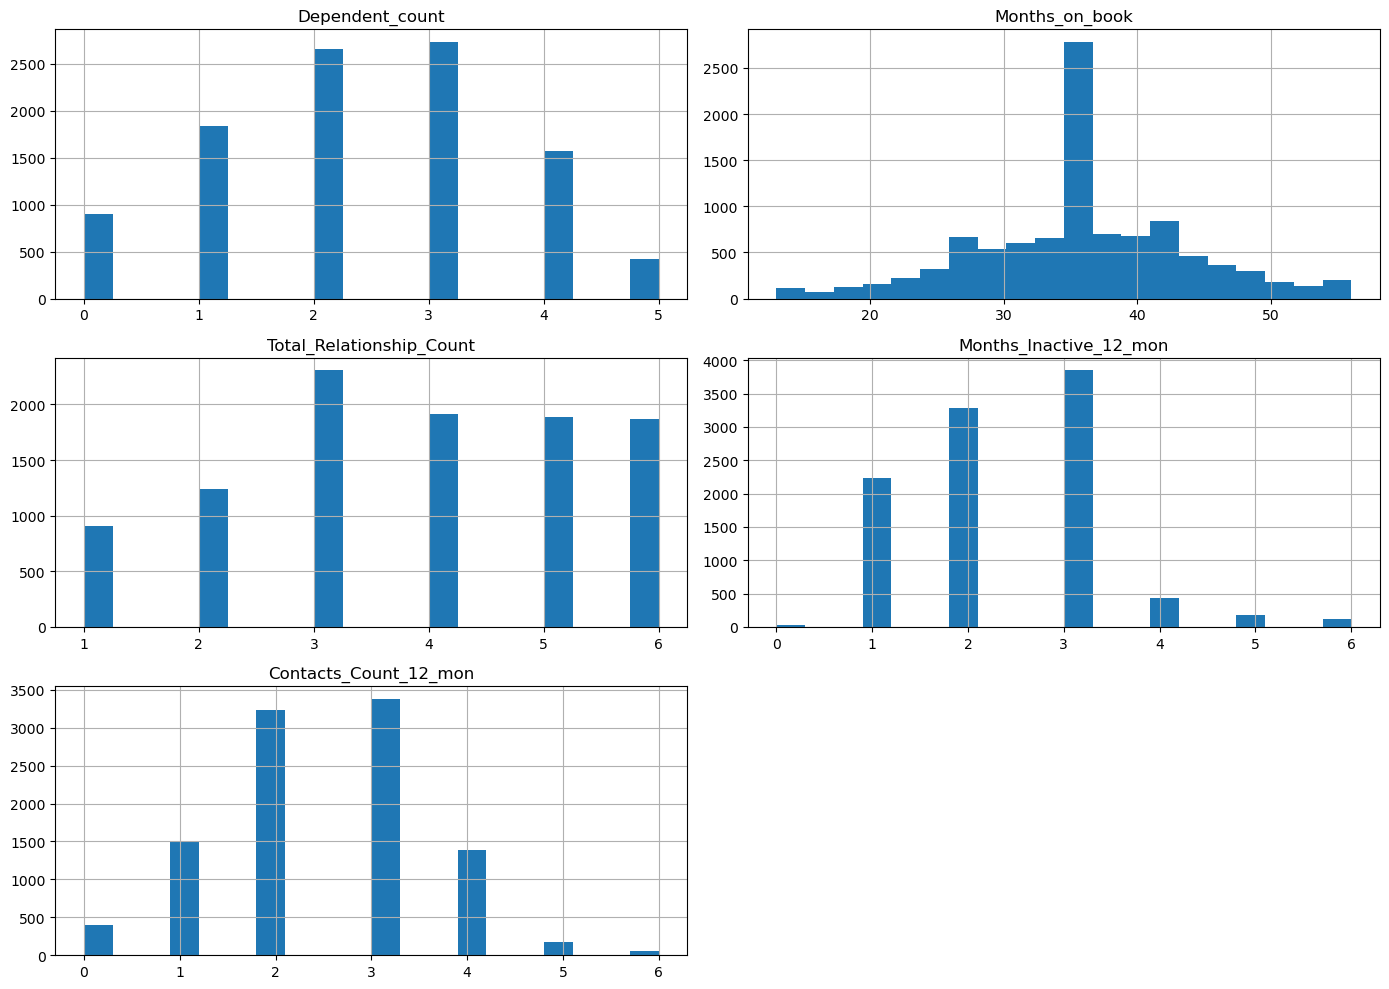

In [27]:
# List of numerical columns in your dataset
numerical_columns = ['Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
                     'Months_Inactive_12_mon', 'Contacts_Count_12_mon']

# Plot histograms for each numerical feature
df[numerical_columns].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

- The `Dependent_count` distribution resembles a bell curve, with most individuals having either 2 or 3 dependents. This indicates a tendency for people to have a moderate number of dependents, with fewer individuals having more or fewer than 2 or 3 dependents.

- From `Total_Relationship_Count`, the majority of customers hold 3 products, while the distribution is fairly even for those with 4, 5, or 6 products. The least common case is customers holding only 1 product.

- `Contacts_Count_12_mon` shows that most customers have made between 1 to 3 contacts.

- The distribution of `Months_on_book` is skewed, with a relatively low count of individuals throughout, each having fewer than 500 records. However, there is a sharp peak at 37 months on book, where the count increases significantly, reaching close to 2,500 individuals.

- From `Months_Inactive_12_mon`, the majority of customers have been inactive for 2 to 3 months.

The following columns exhibits some kind of distribution. We plotted the histograms with kde lines.

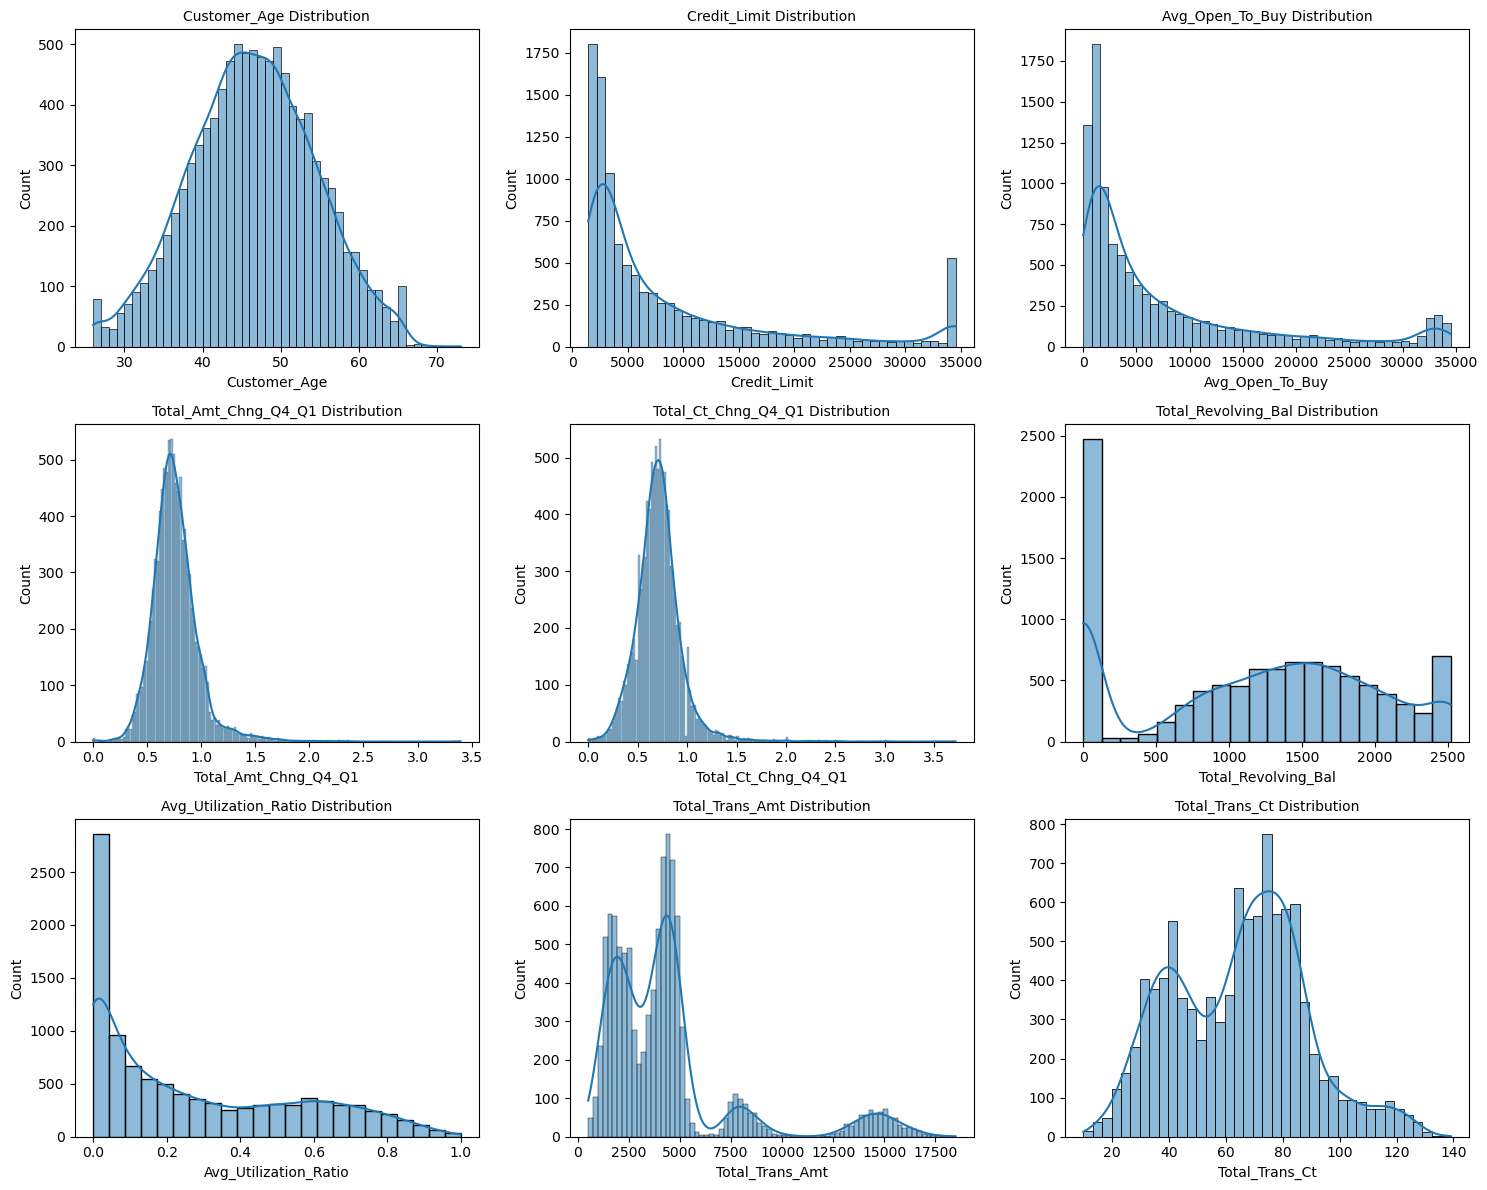

In [28]:
numerical_columns = ['Customer_Age','Credit_Limit','Avg_Open_To_Buy',
                     'Total_Amt_Chng_Q4_Q1','Total_Ct_Chng_Q4_Q1',
                     'Total_Revolving_Bal','Avg_Utilization_Ratio',
                     'Total_Trans_Amt','Total_Trans_Ct']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()  

# plot each column
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])  # Histogram with KDE
    axes[i].set_title(f"{col} Distribution", fontsize=10)

plt.tight_layout()  # Adjust layout
plt.show()

- The distribution of `Customer_Age` follows a bell-shaped curve, with the majority of individuals clustering within the late 40s to early 50s range. This suggests a concentration of people in this age group, with fewer individuals at the younger and older extremes.

- We should note that the distributions of `Credit_Limit` and `Avg_Open_To_Buy` both exhibit a similar pattern, with a high peak at the lower end, followed by a smaller peak at the higher end. This suggests that most individuals fall within the lower to mid-range values, while a smaller subset of individuals exhibits values at the higher end, creating a bimodal distribution with two distinct peaks—one at the beginning and another towards the upper end of the range.

- Furthermore, the distributions for both `Total_Amt_Chng_Q4_Q1` and `Total_Ct_Chng_Q4_Q1`have a similar shape, with a noticeable spike around 0.7. This indicates a concentration of data points around this value, suggesting that the majority of transactions experience a moderate change, with fewer instances of more extreme changes in either amount or count.

- The distributions for both `Total_Revolving_Bal` and `Avg_Utilization_Ratio` show a pronounced peak at the lower end, followed by a more gradual slope as the values increase. This suggests that most individuals have lower balances or utilisation ratios, with a smaller proportion experiencing higher values, leading to a gentle decline after the initial peak.

- The distribution of `Total_Trans_Amt` features two prominent peaks, along with two smaller ones. The first major peak occurs around a transaction count of 470, with a transaction amount of approximately $2000, followed by another significant peak at around 600 transactions, with a total amount near $4,500. Two smaller peaks appear at the higher end: one around 75 transactions, with a total amount of $7500, and another at 70 transactions, with a total amount reaching $14000. This suggests a concentration of transactions at both the lower and higher ends of the amount spectrum, with fewer but larger amounts observed at the peaks on the upper side.

- As for `Total_Trans_Ct`, most individuals will engage in transactions between 30 to 75 times in the last 12 months.

### Categorical Features

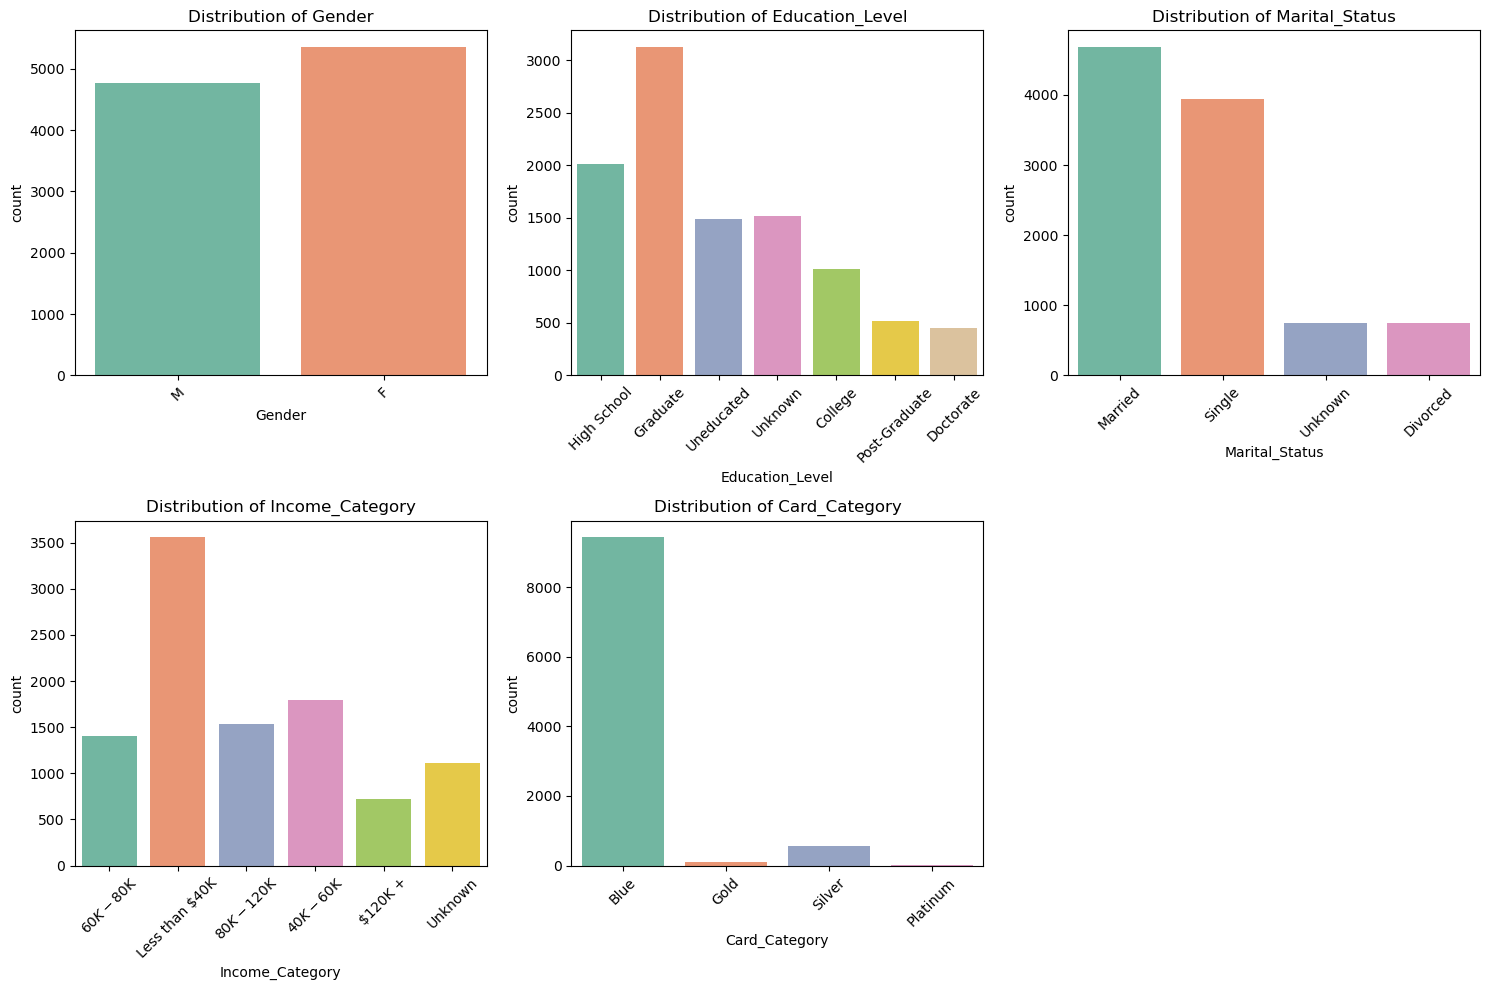

In [39]:
# List of categorical columns to visualize
categorical_columns = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

# Create a figure to display all plots
plt.figure(figsize=(15, 10))

# Loop through each categorical column and create a subplot
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=column, hue=column, palette='Set2', legend=False)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)

plt.tight_layout()

# Show the plot
plt.show()


- `Gender`: The gender distribution is fairly even, with males representing around 4769 individuals and females slightly higher at around 5358.

- `Education_Level`: The majority of individuals have attained a graduate level of education, while fewer hold post-graduate or doctorate degrees, with the latter being the least common educational attainment."

- `Marital_Status`: Most individuals are either married (4700) or single (3900), while the categories of unknown and divorced are less frequent, each with fewer than 1000 individuals.

- `Income_Category`: The distribution of card category shows a large majority of blue card holders, nearing 10000, suggesting a strong preference for this category.

- `Card_Category`: The income distribution reveals that the majority (3500) earn `Less than $40k`, with other categories being relatively even. The only exception is the `$120k+` income category, which is noticeably smaller at around 750 individuals.

### Feature Correlations

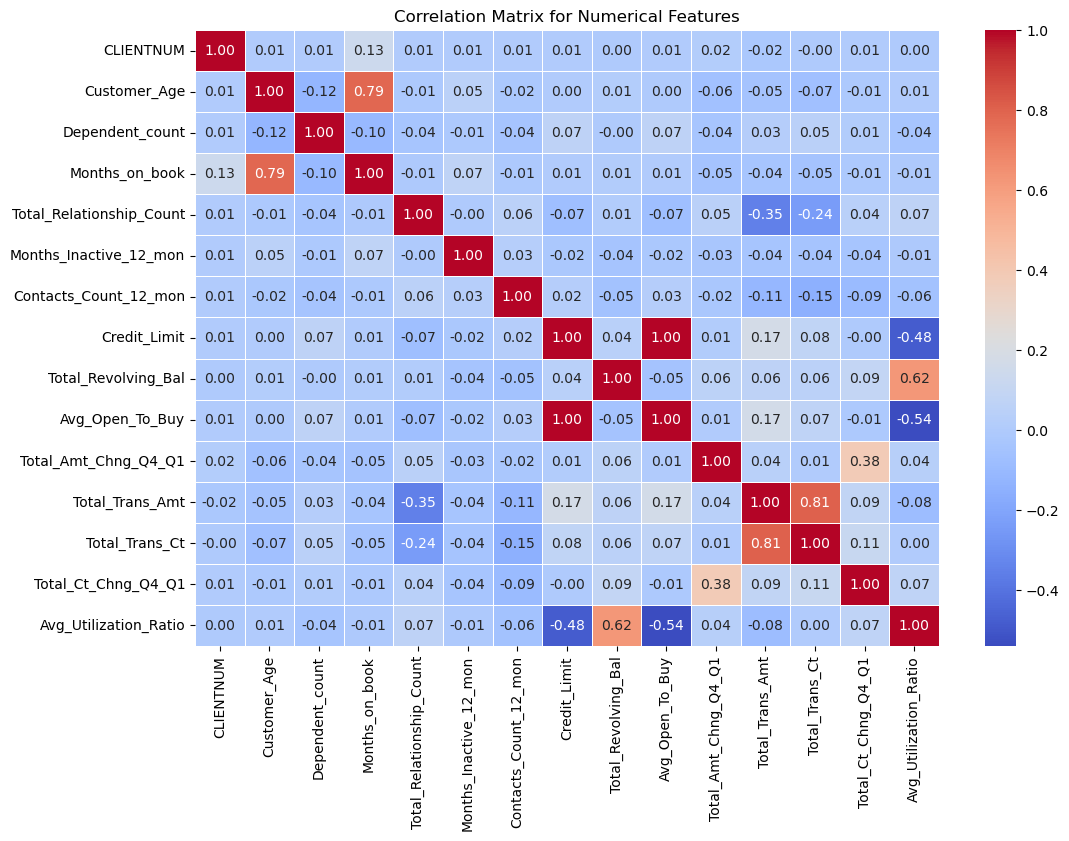

In [40]:
# Select only numeric columns
df_numeric = df.select_dtypes(include=[np.number])  

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

In [41]:

# In order to better interpret the result of the correlation heatmap, we filter out the correlations with
# the absolute value of Pearson Coefficient greater than or equal to 0.5. We consider them as strongly correlated.

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Extract upper triangle (excluding diagonal)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
corr_pairs = corr_matrix.where(mask).stack()

# Remove self-correlations (where a variable is correlated with itself)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Sort by correlation values in descending order
sorted_corr = corr_pairs.sort_values(ascending=False)

# Filter correlations above the threshold
threshold = 0.5
strong_corr = sorted_corr[sorted_corr.abs() >= threshold] 

# Display the results
print(strong_corr)

Credit_Limit         Avg_Open_To_Buy          0.995981
Total_Trans_Amt      Total_Trans_Ct           0.807192
Customer_Age         Months_on_book           0.788912
Total_Revolving_Bal  Avg_Utilization_Ratio    0.624022
Avg_Open_To_Buy      Avg_Utilization_Ratio   -0.538808
dtype: float64


### Analysis of the Correlation Coefficient

Based on the correlation analysis, we identified a few strong relationships among numerical variables. These strong relationships are all as expected by the nature of the variables. For instance, customers who have more transaction count are tend to have a higher transaction amount. People with more revolving balance tend to have a higher average credit utilization ratio.

Overall, the fact that only a few variable have high correlation is a positive sign, suggesting that most features provide unique information rather than being redundant. This ensures a more meaningful and diverse set of predictors for further analysis.